# NNDL Week 3

**Name: Shashank Goel**
**Roll no: J011**
**SAP ID: 70092300008**
**Batch: B.Tech Data Science**

# Neural Networks

- High bias --> Underfitting
- High variance --> Overfitting

## Bias-variance tradeoff

- More data ---> more bias. A complex model solves bias
- More data lowers variance.


## Xaiver Initialization
The goal of Xavier Initialization is to initialize the weights such that the variance of the activations 
are the same across every layer. 

This constant variance helps prevent the gradient from exploding or vanishing.

Assumptions:
- Weights and inputs are centered at zero
- Weights and inputs are independent and identically distributed
- Biases are initialized as zeros
- We use the tanh() activation function, which is approximately linear with small inputs: 
    Var(a[l]) ≈ Var(z[l])

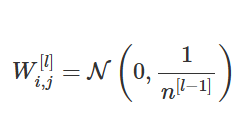
- Assign iniital weights to be 1/n (Number of input nodes).


### How to solve exploding gradient?
- Regularization (L1, L2)
- Dropout
- Batch Normalization

## Combatting Overfitting & Underfitting
Overfitting:
- Increase amount of data
- Utilize data augmentation methods
- Decrease model size/complexity
- Implement early stopping
- Utilize regularization techniques


Underfitting:
- Increase model size and complexity
- Train for a longer period of time
- Reduce regularization techniques

## L2 (Ridge)

$$
J(W) =
\frac{1}{m}
\sum_{i=1}^{m}
\mathcal{L}\left(\hat{y}^{(i)}, y^{(i)}\right)
+
\frac{\lambda}{2m}
\sum_{l=1}^{L}
\left\|W^{(l)}\right\|_F^2
$$

lambda = 0          --> overfit
lamda too high      --> underfit
lambda just right   --> perfect result

## L1 (Lasso)

$$
J(W) =
\frac{1}{m}
\sum_{i=1}^{m}
\mathcal{L}\left(\hat{y}^{(i)}, y^{(i)}\right)
+
\frac{\lambda}{m}
\sum_{l=1}^{L}
\left\|W^{(l)}\right\|_1
$$

In [1]:
import os
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3" # Suppress TensorFlow logging (1)
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras

In [2]:
[(X_train, y_train), (X_test, y_test)] = keras.datasets.fashion_mnist.load_data()

In [3]:
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
X_train = (X_train / 255.0).astype(np.float32)
X_test = (X_test / 255.0).astype(np.float32)

X_train = X_train[:2000]
X_test = X_test[:200]

y_train = y_train[:2000]
y_test = y_test[:200]

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)


X_train shape: (60000, 28, 28)
X_test shape: (10000, 28, 28)
X_train shape: (2000, 28, 28)
X_test shape: (200, 28, 28)


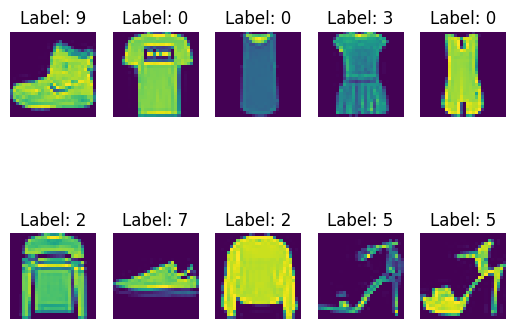

In [4]:
for i in range(10):
    plt.subplot(2, 5, i+1)
    plt.imshow(X_train[i])
    plt.title(f"Label: {y_train[i]}")
    plt.axis('off')

In [5]:
y_train[:10]

array([9, 0, 0, 3, 0, 2, 7, 2, 5, 5], dtype=uint8)

In [6]:
model= keras.Sequential([
    keras.Input(shape=(28, 28)),
    keras.layers.Flatten(),
    keras.layers.Dense(256, activation='relu'),
    keras.layers.Dense(128, activation='relu'),
    keras.layers.Dense(10, activation='softmax')
])

In [7]:
model.compile(optimizer= 'adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

In [8]:
history = model.fit(X_train, y_train, 
                    validation_data=(X_test, y_test), 
                    epochs = 20, batch_size = 32, verbose=0)

In [9]:
train_acc = history.history['accuracy'][-1]
test_acc = history.history['val_accuracy'][-1]

print(f'Training Accuracy: {train_acc:.4f}')
print(f'Test Accuracy: {test_acc:.4f}')

Training Accuracy: 0.9475
Test Accuracy: 0.8450


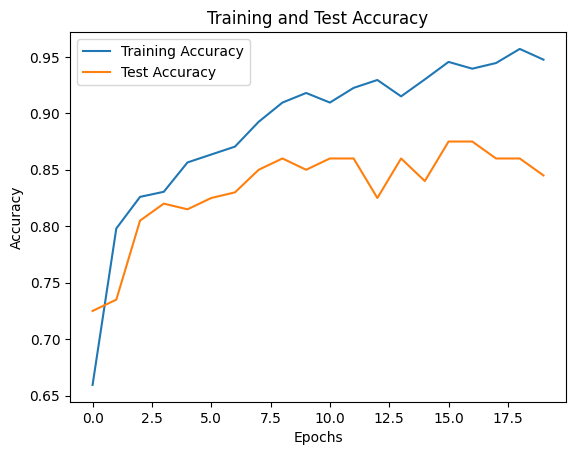

In [10]:
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Test Accuracy')
plt.title('Training and Test Accuracy')
plt.legend()
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.show()

In [4]:
def train_model(name, model, epochs, callback = None, verbose = 0):

    print(f"Training {name} for {epochs} epochs")

    model.compile(optimizer= 'adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    history = model.fit(X_train, y_train, 
                    validation_data=(X_test, y_test), 
                    epochs = epochs, batch_size = 32, 
                    verbose=verbose, callbacks = callback)

    train_acc = history.history['accuracy'][-1]
    test_acc = history.history['val_accuracy'][-1]
    print(f'Training Accuracy: {train_acc:.4f}, Test Accuracy: {test_acc:.4f}')

    plt.plot(history.history['accuracy'], label='Training Accuracy')
    plt.plot(history.history['val_accuracy'], label='Test Accuracy')
    plt.title('Training and Test Accuracy')
    plt.legend()
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.show()

    return history

Training Base Model for 50 epochs
Training Accuracy: 0.9540, Test Accuracy: 0.8350


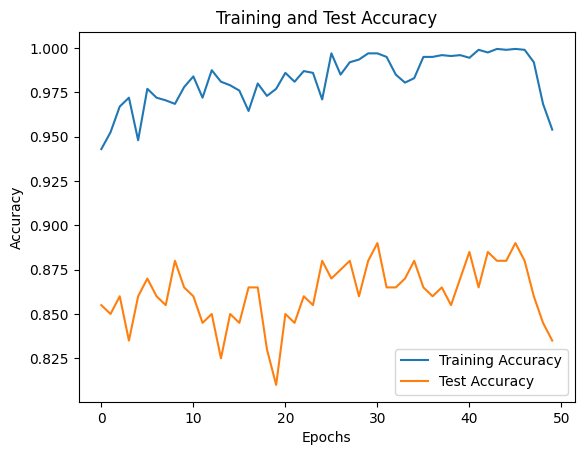

In [12]:
train_model("Base Model", model, 50)

Training Overfitting Model for 50 epochs
Training Accuracy: 0.9890, Test Accuracy: 0.8700


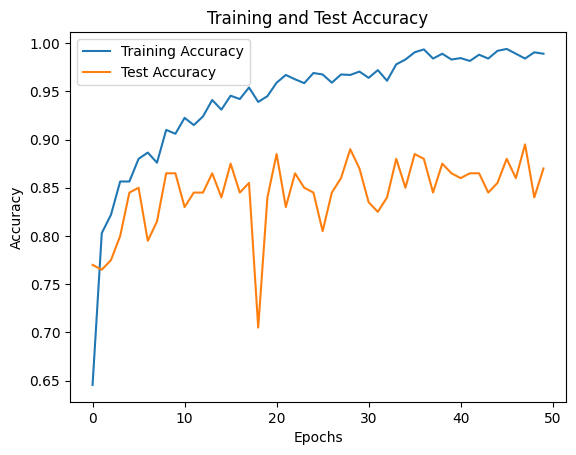

In [13]:
# Overfitting model

model_1 = keras.Sequential([
    keras.Input(shape=(28, 28)),
    keras.layers.Flatten(),
    keras.layers.Dense(256, activation='relu'),
    keras.layers.Dense(256, activation='relu'),
    keras.layers.Dense(10, activation='softmax')
])

train_model("Overfitting Model", model_1, 50)

Training L2 Regularization Model for 100 epochs
Training Accuracy: 0.9215, Test Accuracy: 0.8300


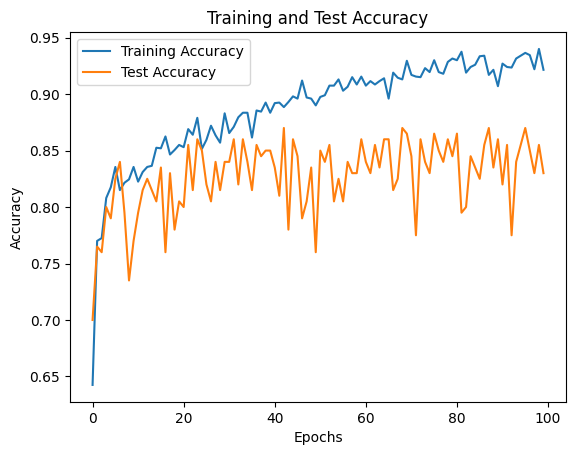

In [14]:
# L2 regularization model

model_2 = keras.Sequential([
    keras.Input(shape=(28, 28)),
    keras.layers.Flatten(),
    keras.layers.Dense(256, activation='relu', kernel_regularizer=keras.regularizers.l2(0.01)),
    keras.layers.Dense(256, activation='relu', kernel_regularizer=keras.regularizers.l2(0.01)),
    keras.layers.Dense(10, activation='softmax')
])

train_model("L2 Regularization Model", model_2, 100)

Training L2 Regularization Model for 100 epochs
Training Accuracy: 0.1020, Test Accuracy: 0.1350


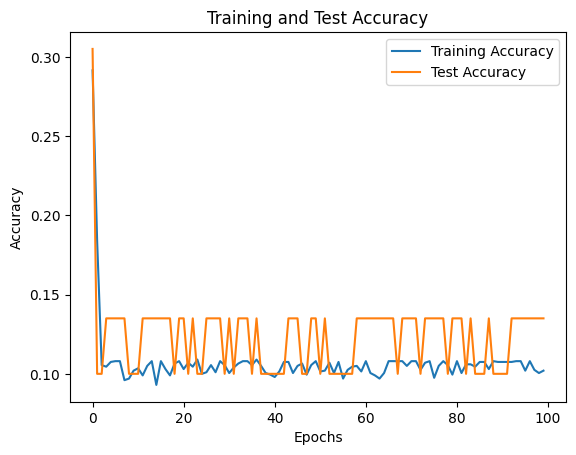

In [15]:
model_3 = keras.Sequential([
    keras.Input(shape=(28, 28)),
    keras.layers.Flatten(),
    keras.layers.Dense(256, activation='relu', kernel_regularizer=keras.regularizers.l2(3000)),
    keras.layers.Dense(256, activation='relu', kernel_regularizer=keras.regularizers.l2(3000)),
    keras.layers.Dense(10, activation='softmax')
])

train_model("L2 Regularization Model", model_3, 100)

Training L2 Regularization Model for 100 epochs
Training Accuracy: 0.6055, Test Accuracy: 0.5850


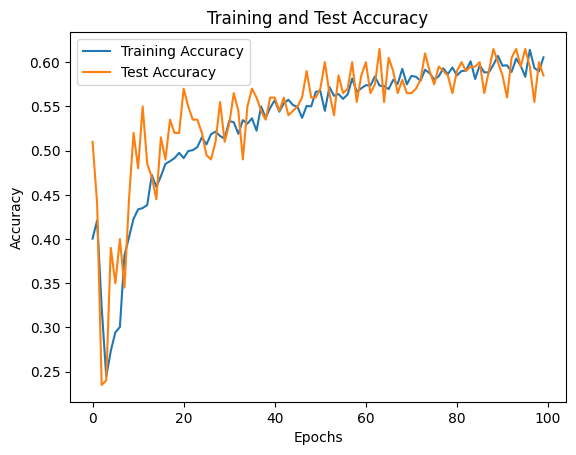

In [16]:
model_4 = keras.Sequential([
    keras.Input(shape=(28, 28)),
    keras.layers.Flatten(),
    keras.layers.Dense(256, activation='relu', kernel_regularizer=keras.regularizers.l2(1)),
    keras.layers.Dense(256, activation='relu', kernel_regularizer=keras.regularizers.l2(1)),
    keras.layers.Dense(10, activation='softmax')
])

train_model("L2 Regularization Model", model_4, 100)

Training Dropout Model for 50 epochs
Training Accuracy: 0.8980, Test Accuracy: 0.8700


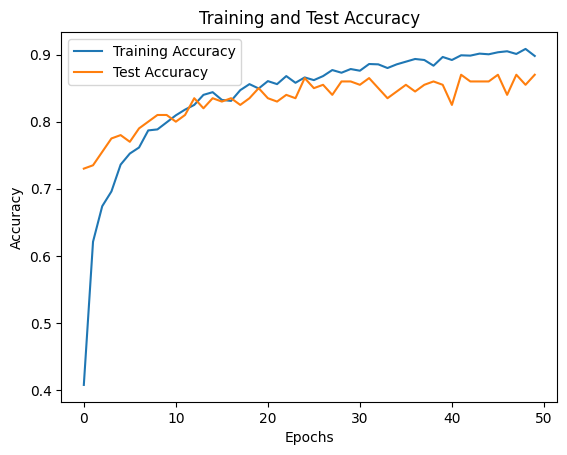

In [17]:
# Dropout

model = keras.Sequential([
    keras.Input(shape=(28, 28)),
    keras.layers.Flatten(),
    keras.layers.Dense(256, activation='relu'),
    keras.layers.Dropout(0.5),
    keras.layers.Dense(128, activation='relu'),
    keras.layers.Dropout(0.5),
    keras.layers.Dense(10, activation = "softmax")
])

train_model("Dropout Model", model, 50)

Training Early Stopping Model for 60 epochs
Epoch 1/60
63/63 ━━━━━━━━━━━━━━━━━━━━ 4s 21ms/step - accuracy: 0.6425 - loss: 1.0172 - val_accuracy: 0.7200 - val_loss: 0.7768
Epoch 2/60
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.7905 - loss: 0.6023 - val_accuracy: 0.7500 - val_loss: 0.6664
Epoch 3/60
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.8155 - loss: 0.5383 - val_accuracy: 0.7850 - val_loss: 0.5304
Epoch 4/60
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.8350 - loss: 0.4511 - val_accuracy: 0.8300 - val_loss: 0.4793
Epoch 5/60
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.8480 - loss: 0.4138 - val_accuracy: 0.8150 - val_loss: 0.4278
Epoch 6/60
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.8745 - loss: 0.3641 - val_accuracy: 0.8350 - val_loss: 0.4310
Epoch 7/60
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 0.8745 - loss: 0.3309 - val_accuracy: 0.8250 - val_loss: 0.4945
Epoch 8/60
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.87

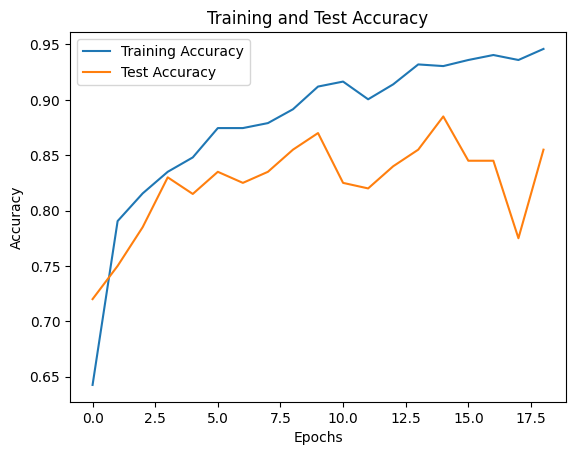

In [18]:
# Early stopping

model = keras.Sequential([
    keras.Input(shape=(28, 28)),
    keras.layers.Flatten(),
    keras.layers.Dense(256, activation='relu'),
    keras.layers.Dense(128, activation='relu'),
    keras.layers.Dense(10, activation = "softmax")
])

stopper = keras.callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
train_model("Early Stopping Model", model, 60, callback=stopper, verbose = 1)

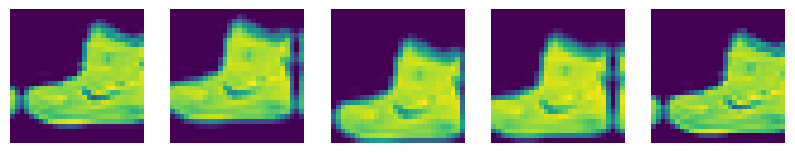

In [19]:
# Augmentation

shift = keras.layers.RandomTranslation(height_factor=0.1, width_factor=0.1) # Shift the image by 10% of the height and width
one = X_train[0].reshape(1, 28, 28, 1)

plt.figure(figsize=(10, 5))
for i in range(5):
    plt.subplot(1, 5, i+1)
    plt.imshow(shift(one, training=True).numpy().reshape(28, 28))
    plt.axis('off')


Training Augmentation Model for 50 epochs
Training Accuracy: 0.8495, Test Accuracy: 0.8250


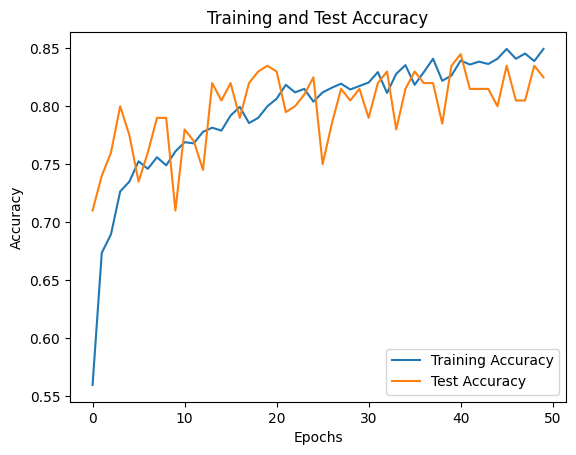

In [20]:
aug_model = keras.Sequential([
    keras.Input(shape=(28, 28)),
    keras.layers.Reshape((28, 28, 1)),
    keras.layers.RandomTranslation(height_factor=0.1, width_factor=0.1),
    keras.layers.Flatten(),
    keras.layers.Dense(256, activation='relu'),
    keras.layers.Dense(128, activation='relu'),
    keras.layers.Dense(10, activation = "softmax")
])

train_model("Augmentation Model", aug_model, 50)

Training All Techniques Model for 100 epochs
Epoch 1/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 7s 43ms/step - accuracy: 0.3635 - loss: 3.8951 - val_accuracy: 0.6450 - val_loss: 2.7004
Epoch 2/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.5280 - loss: 2.7170 - val_accuracy: 0.6650 - val_loss: 2.0916
Epoch 3/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.5850 - loss: 2.2044 - val_accuracy: 0.7150 - val_loss: 1.7138
Epoch 4/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.6225 - loss: 1.9008 - val_accuracy: 0.7000 - val_loss: 1.5448
Epoch 5/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.6375 - loss: 1.7032 - val_accuracy: 0.7250 - val_loss: 1.3645
Epoch 6/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.6365 - loss: 1.5846 - val_accuracy: 0.7200 - val_loss: 1.3383
Epoch 7/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.6500 - loss: 1.4951 - val_accuracy: 0.7400 - val_loss: 1.1948
Epoch 8/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accur

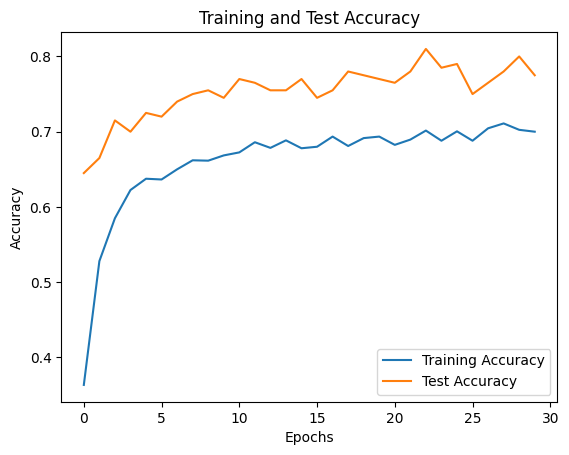

In [21]:
all_model = keras.Sequential([
    keras.Input(shape=(28, 28)),
    keras.layers.Reshape((28, 28, 1)),
    keras.layers.RandomTranslation(height_factor=0.1, width_factor=0.1),
    keras.layers.Flatten(),
    keras.layers.Dense(256, activation='relu', kernel_regularizer=keras.regularizers.l2(0.005)),
    keras.layers.Dropout(0.4),
    keras.layers.Dense(128, activation='relu', kernel_regularizer=keras.regularizers.l2(0.005)),
    keras.layers.Dropout(0.4),
    keras.layers.Dense(10, activation = "softmax")
])


stopper = keras.callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
train_model("All Techniques Model", all_model, 100, callback=stopper, verbose = 1)

Training All Techniques Model for 1000 epochs
Epoch 1/1000
63/63 ━━━━━━━━━━━━━━━━━━━━ 9s 35ms/step - accuracy: 0.2630 - loss: 6.7707 - val_accuracy: 0.4200 - val_loss: 4.4092
Epoch 2/1000
63/63 ━━━━━━━━━━━━━━━━━━━━ 2s 26ms/step - accuracy: 0.3935 - loss: 3.7184 - val_accuracy: 0.4050 - val_loss: 2.9172
Epoch 3/1000
63/63 ━━━━━━━━━━━━━━━━━━━━ 2s 24ms/step - accuracy: 0.4330 - loss: 2.7134 - val_accuracy: 0.4400 - val_loss: 2.3085
Epoch 4/1000
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - accuracy: 0.4530 - loss: 2.2384 - val_accuracy: 0.3900 - val_loss: 2.0859
Epoch 5/1000
63/63 ━━━━━━━━━━━━━━━━━━━━ 2s 27ms/step - accuracy: 0.4560 - loss: 2.0138 - val_accuracy: 0.5550 - val_loss: 1.7484
Epoch 6/1000
63/63 ━━━━━━━━━━━━━━━━━━━━ 2s 24ms/step - accuracy: 0.4760 - loss: 1.8311 - val_accuracy: 0.5700 - val_loss: 1.5510
Epoch 7/1000
63/63 ━━━━━━━━━━━━━━━━━━━━ 2s 27ms/step - accuracy: 0.4890 - loss: 1.7644 - val_accuracy: 0.4750 - val_loss: 1.6714
Epoch 8/1000
63/63 ━━━━━━━━━━━━━━━━━━━━ 2s 24ms/ste

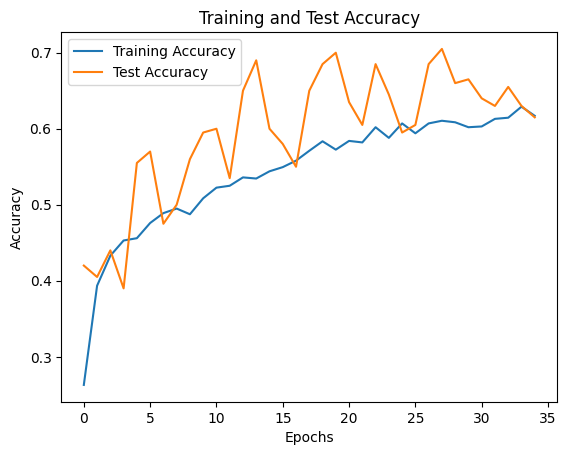

In [22]:
all_model_1 = keras.Sequential([
    keras.Input(shape=(28, 28)),
    keras.layers.Reshape((28, 28, 1)),
    keras.layers.RandomTranslation(height_factor=0.1, width_factor=0.1),
    keras.layers.RandomRotation(factor=0.01),
    keras.layers.RandomContrast(factor=0.1),
    keras.layers.RandomCrop(height=24, width=24),
    keras.layers.Resizing(28, 28),
    keras.layers.RandomFlip(mode= 'horizontal_and_vertical'),
    keras.layers.Flatten(),
    keras.layers.Dense(1026, activation='relu', kernel_regularizer=keras.regularizers.l2(0.005)),
    keras.layers.Dense(256, activation='relu', kernel_regularizer=keras.regularizers.l2(0.005)),
    keras.layers.Dropout(0.4),
    keras.layers.Dense(128, activation='relu', kernel_regularizer=keras.regularizers.l2(0.005)),
    keras.layers.Dropout(0.4),
    keras.layers.Dense(10, activation = "softmax")
])


stopper = keras.callbacks.EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True)
train_model("All Techniques Model", all_model_1, 1000, callback=stopper, verbose = 1)

Training Final Model for 1000 epochs
Epoch 1/1000
63/63 ━━━━━━━━━━━━━━━━━━━━ 13s 136ms/step - accuracy: 0.3360 - loss: 13.5718 - val_accuracy: 0.4550 - val_loss: 4.9605
Epoch 2/1000
63/63 ━━━━━━━━━━━━━━━━━━━━ 6s 92ms/step - accuracy: 0.4235 - loss: 3.6716 - val_accuracy: 0.4400 - val_loss: 2.7803
Epoch 3/1000
63/63 ━━━━━━━━━━━━━━━━━━━━ 10s 81ms/step - accuracy: 0.4685 - loss: 2.5245 - val_accuracy: 0.5300 - val_loss: 2.1248
Epoch 4/1000
63/63 ━━━━━━━━━━━━━━━━━━━━ 4s 69ms/step - accuracy: 0.4860 - loss: 2.1128 - val_accuracy: 0.5950 - val_loss: 1.7875
Epoch 5/1000
63/63 ━━━━━━━━━━━━━━━━━━━━ 4s 59ms/step - accuracy: 0.4730 - loss: 1.9694 - val_accuracy: 0.4850 - val_loss: 1.8283
Epoch 6/1000
63/63 ━━━━━━━━━━━━━━━━━━━━ 4s 62ms/step - accuracy: 0.5075 - loss: 1.8083 - val_accuracy: 0.5800 - val_loss: 1.5922
Epoch 7/1000
63/63 ━━━━━━━━━━━━━━━━━━━━ 4s 67ms/step - accuracy: 0.5195 - loss: 1.7134 - val_accuracy: 0.6150 - val_loss: 1.5013
Epoch 8/1000
63/63 ━━━━━━━━━━━━━━━━━━━━ 4s 66ms/step - a

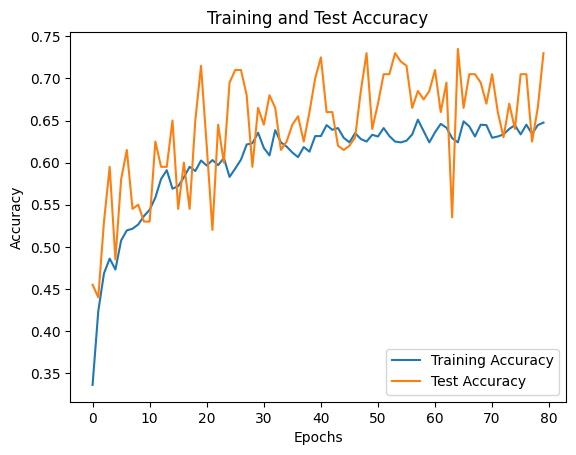

In [23]:
# Final model giving highest accuracy

final_model = keras.Sequential([
    keras.Input(shape=(28, 28)),
    keras.layers.Reshape((28, 28, 1)),
    keras.layers.RandomTranslation(height_factor=0.1, width_factor=0.1),
    keras.layers.RandomRotation(factor=0.01),
    keras.layers.RandomContrast(factor=0.1),
    keras.layers.RandomCrop(height=24, width=24),
    keras.layers.Resizing(28, 28),
    keras.layers.Flatten(),
    keras.layers.Dense(2052, activation='relu', kernel_regularizer=keras.regularizers.l2(0.01)),
    keras.layers.Dropout(0.2),
    keras.layers.Dense(1026, activation='relu', kernel_regularizer=keras.regularizers.l2(0.01)),
    keras.layers.Dense(256, activation='relu', kernel_regularizer=keras.regularizers.l2(0.01)),
    keras.layers.Dropout(0.4),
    keras.layers.Dense(128, activation='relu', kernel_regularizer=keras.regularizers.l2(0.01)),
    keras.layers.Dense(10, activation = "softmax")
])

stopper = keras.callbacks.EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True)
train_model("Final Model", final_model, 1000, callback=stopper, verbose = 1)

### This ipynb is submitted by Shashank Goel